In [37]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.io
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.layers import Conv2D, MaxPool2D
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from mlxtend.plotting import plot_confusion_matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score, accuracy_score
from sklearn.metrics import hamming_loss


In [38]:
mat_data   = scipy.io.loadmat('../../datasets/UniMiB-SHAR/data/acc_data.mat')
mat_labels = scipy.io.loadmat('../../datasets/UniMiB-SHAR/data/acc_labels.mat')


In [39]:
print("acc_data shape:  ", mat_data['acc_data'].shape)
print("acc_labels shape:", mat_labels['acc_labels'].shape)
print("acc_labels first 5 rows:\n", mat_labels['acc_labels'][:5])


acc_data shape:   (11771, 453)
acc_labels shape: (11771, 3)
acc_labels first 5 rows:
 [[1 1 1]
 [1 1 1]
 [1 1 1]
 [1 1 2]
 [1 1 2]]


In [40]:
X = mat_data['acc_data']                      # shape: (11771, 453)
y = mat_labels['acc_labels'][:, 0].squeeze()  # shape: (11771,) - activity labels only


In [41]:
if len(X.shape) == 2:
    X = X.reshape(-1, 151, 3)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (11771, 151, 3)
y shape: (11771,)


In [42]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Any NaN in X:", np.isnan(X).any())
print("Any NaN in y:", np.isnan(y.astype(float)).any())
print("X dtype:", X.dtype)
print("y dtype:", y.dtype)

X shape: (11771, 151, 3)
y shape: (11771,)
Any NaN in X: False
Any NaN in y: False
X dtype: float64
y dtype: uint8


In [43]:
Fs = 50
X = X.astype('float32')
y = y.astype('int32')

activity_names = [
    'StandingUpFS',    # 1
    'StandingUpFL',    # 2
    'Walking',         # 3
    'Running',         # 4
    'GoingUpS',        # 5
    'Jumping',         # 6
    'GoingDownS',      # 7
    'LyingDownFS',     # 8
    'SittingDown',     # 9
    'FallingForw',     # 10
    'FallingRight',    # 11
    'FallingBack',     # 12
    'HittingObstacle', # 13
    'FallingWithPS',   # 14
    'FallingBackSC',   # 15
    'Syncope',         # 16
    'FallingLeft'      # 17
]
activities = np.unique(y)
print("Activities:", activities)

Activities: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17]


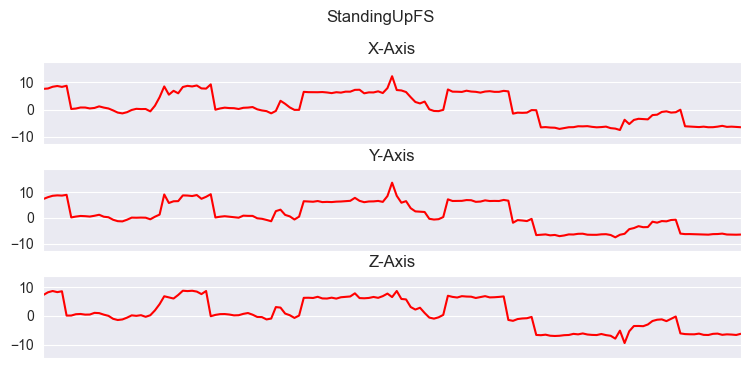

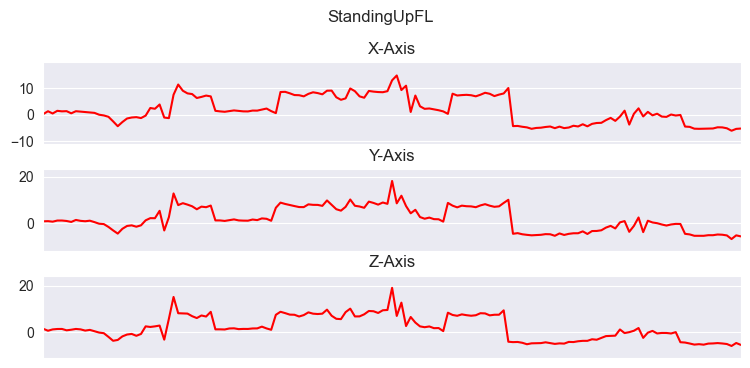

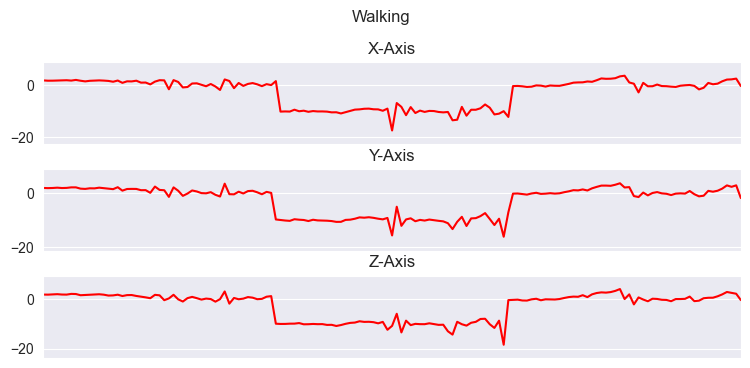

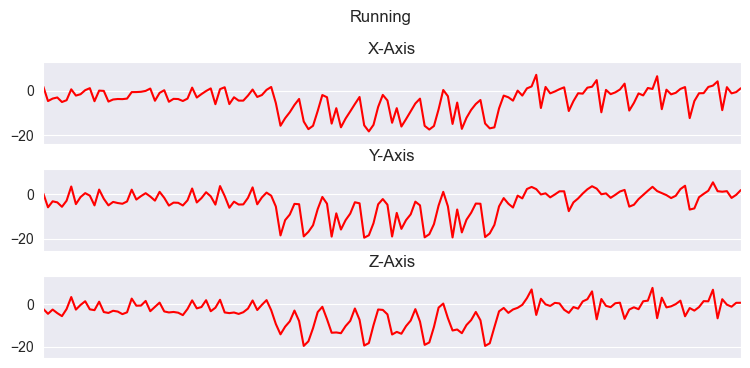

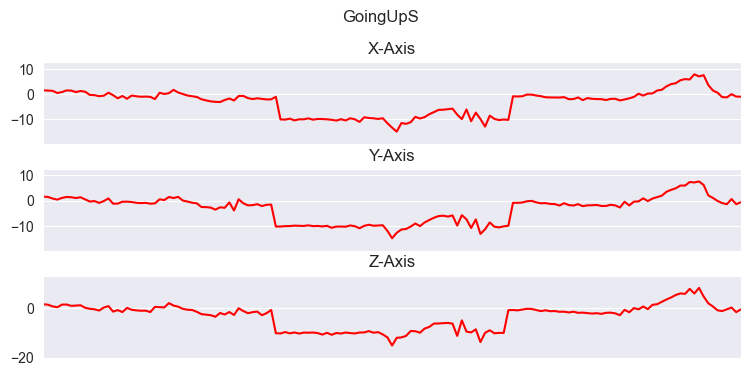

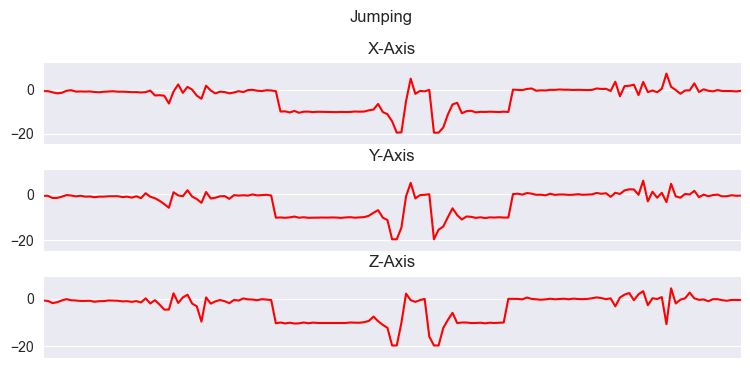

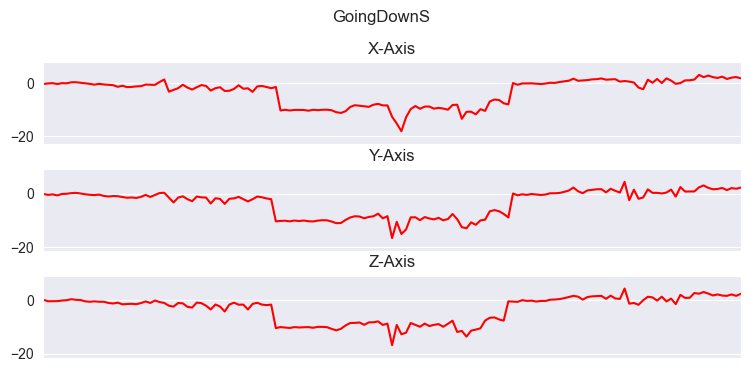

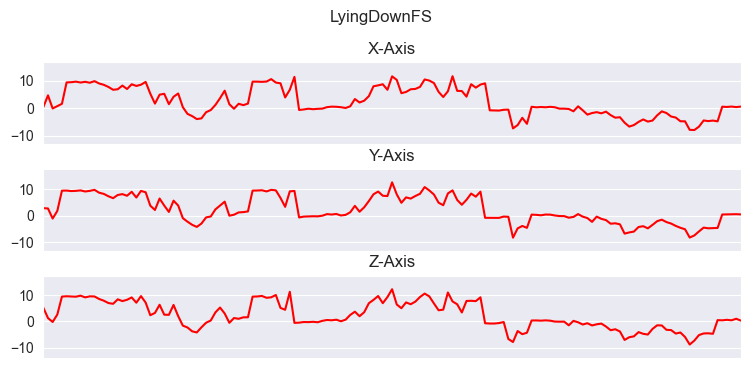

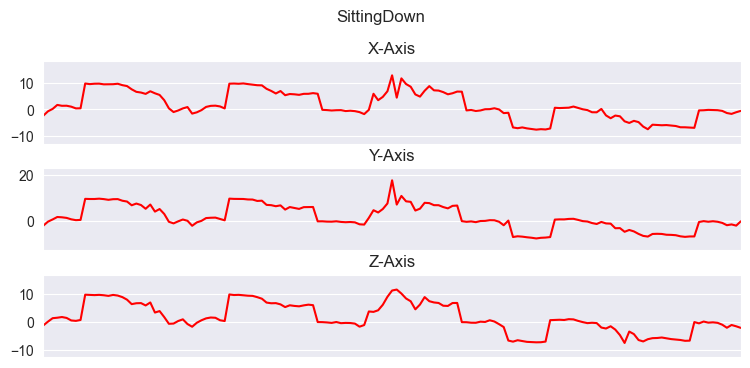

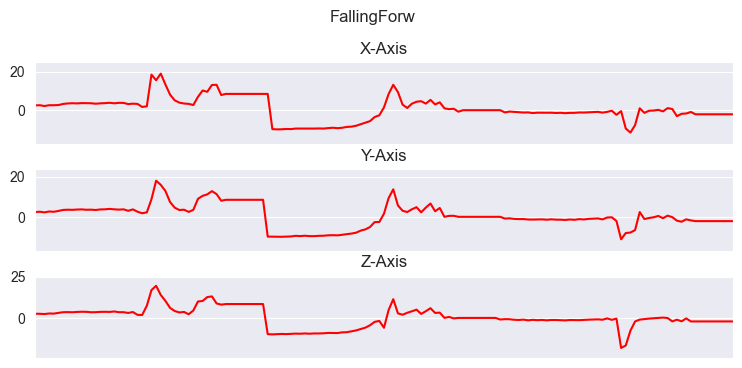

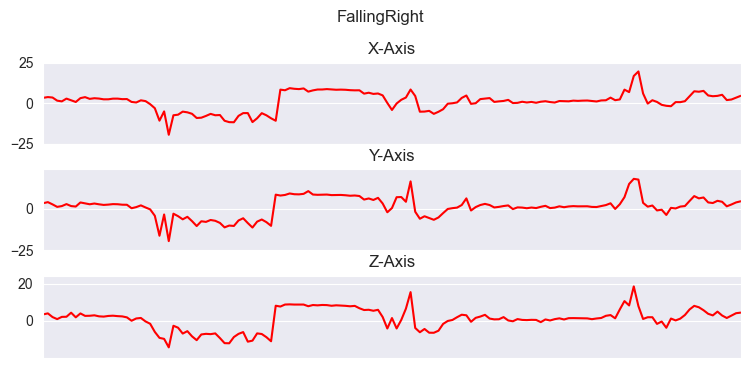

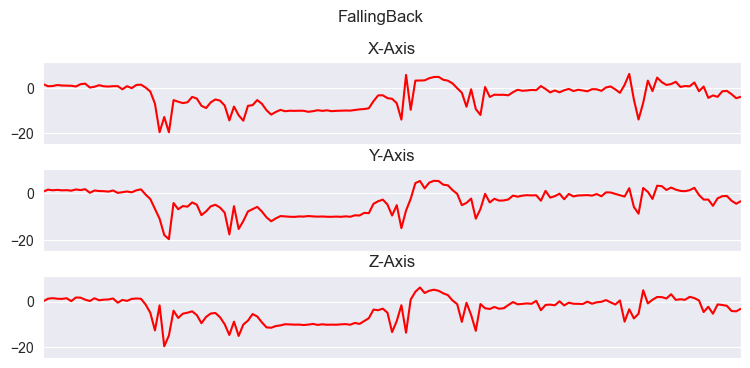

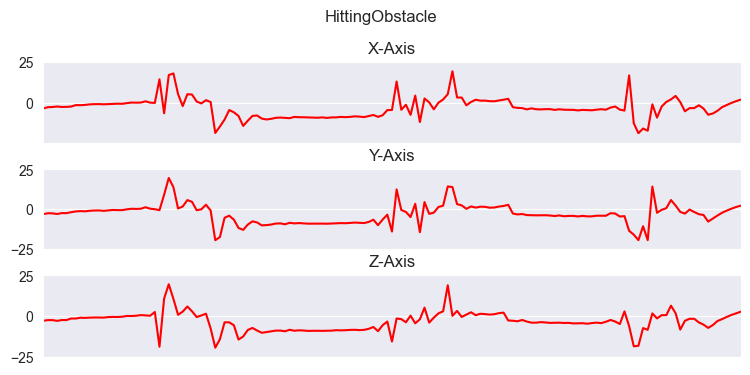

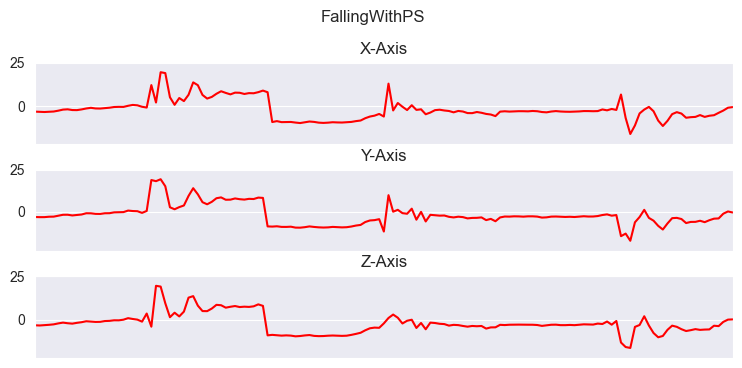

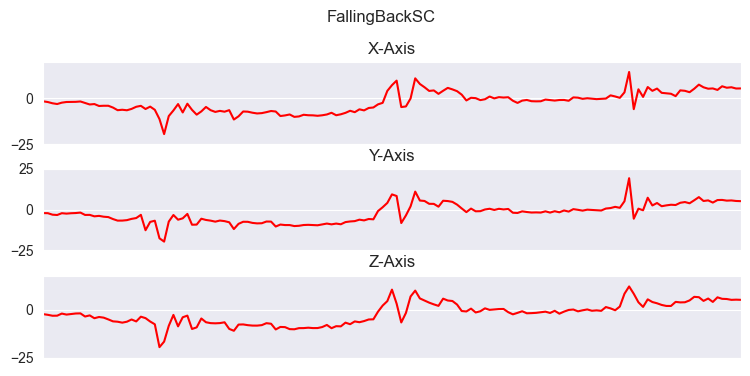

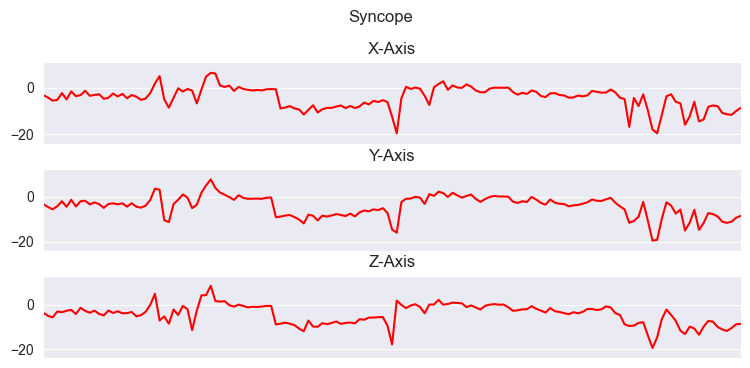

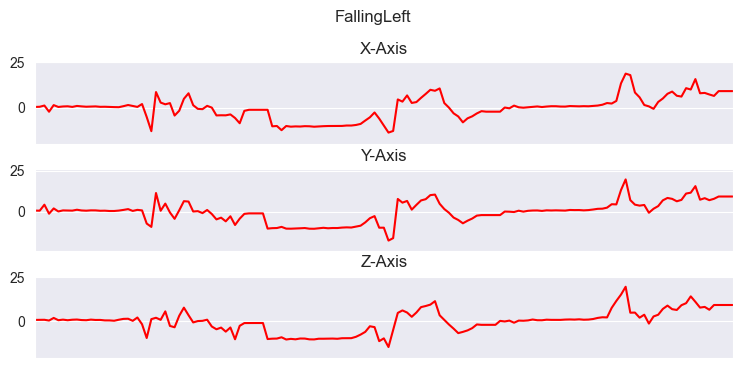

In [44]:
def plot_activity(activity_id, X, y, activity_names):
    idx    = np.where(y == activity_id)[0][0]
    sample = X[idx]  # shape: (151, 3)
    time   = np.arange(sample.shape[0])  # CHANGED: use sample index as x-axis

    fig, (ax0, ax1, ax2) = plt.subplots(nrows=3, figsize=(9, 4), sharex=True)
    plot_axis(ax0, time, sample[:, 0], 'X-Axis')
    plot_axis(ax1, time, sample[:, 1], 'Y-Axis')
    plot_axis(ax2, time, sample[:, 2], 'Z-Axis')
    plt.subplots_adjust(hspace=0.3)
    fig.suptitle(activity_names[activity_id - 1])  # CHANGED: use activity_names list
    plt.subplots_adjust(top=0.85)
    plt.show()

def plot_axis(ax, x, y, title):
    ax.plot(x, y, 'r')
    ax.set_title(title)
    ax.xaxis.set_visible(False)
    ax.set_ylim([min(y) - np.std(y), max(y) + np.std(y)])
    ax.set_xlim([min(x), max(x)])
    ax.grid(True)

for activity_id in activities:
    plot_activity(activity_id, X, y, activity_names)


In [45]:
df = pd.DataFrame({
    'x':        X[:, :, 0].tolist(),   # store each (151,) array as a list in the cell
    'y':        X[:, :, 1].tolist(),
    'z':        X[:, :, 2].tolist(),
    'activity': [activity_names[int(a) - 1] for a in y]
})
df.head()
df['activity'].value_counts()

activity
Running            1985
Walking            1738
GoingDownS         1324
GoingUpS            921
Jumping             746
HittingObstacle     661
FallingLeft         534
FallingForw         529
FallingBack         526
Syncope             513
FallingRight        511
FallingWithPS       484
FallingBackSC       434
LyingDownFS         296
StandingUpFL        216
SittingDown         200
StandingUpFS        153
Name: count, dtype: int64

In [46]:
min_count = df['activity'].value_counts().min()
print("Minimum class count (used for balancing):", min_count)

balanced_data = pd.concat(
    [df[df['activity'] == act].head(min_count).copy() for act in activity_names],
    ignore_index=True
)
print("Balanced data shape:", balanced_data.shape)

Minimum class count (used for balancing): 153
Balanced data shape: (2601, 4)


In [47]:
balanced_data['activity'].value_counts()

activity
StandingUpFS       153
StandingUpFL       153
Walking            153
Running            153
GoingUpS           153
Jumping            153
GoingDownS         153
LyingDownFS        153
SittingDown        153
FallingForw        153
FallingRight       153
FallingBack        153
HittingObstacle    153
FallingWithPS      153
FallingBackSC      153
Syncope            153
FallingLeft        153
Name: count, dtype: int64

In [48]:
balanced_data.head()

,x,y,z,activity
0,"[7.609005451202393, 7.753252983093262, 8.38874...","[7.322881698608398, 8.043098449707031, 8.57803...","[7.281457901000977, 8.215853691101074, 8.65835...",StandingUpFS
1,"[8.507708549499512, 8.863954544067383, 7.78231...","[8.48092269897461, 8.863968849182129, 7.412025...","[8.747757911682129, 8.458413124084473, 7.58906...",StandingUpFS
2,"[8.44204044342041, 8.697697639465332, 0.395887...","[8.632097244262695, 8.55264949798584, -0.09075...","[8.730011940002441, 8.057507514953613, -0.3355...",StandingUpFS
3,"[-11.025566101074219, -9.944633483886719, -7.6...","[-11.714652061462402, -7.66016960144043, -9.16...","[-11.76520824432373, -6.88215970993042, -10.33...",StandingUpFS
4,"[0.23847155272960663, 0.4957669973373413, 1.01...","[0.32154884934425354, 0.6645562052726746, 1.01...","[0.3838018774986267, 0.7762642502784729, 0.850...",StandingUpFS


In [49]:
label = LabelEncoder()
balanced_data['label'] = label.fit_transform(balanced_data['activity'])
balanced_data.head()

,x,y,z,activity,label
0,"[7.609005451202393, 7.753252983093262, 8.38874...","[7.322881698608398, 8.043098449707031, 8.57803...","[7.281457901000977, 8.215853691101074, 8.65835...",StandingUpFS,14
1,"[8.507708549499512, 8.863954544067383, 7.78231...","[8.48092269897461, 8.863968849182129, 7.412025...","[8.747757911682129, 8.458413124084473, 7.58906...",StandingUpFS,14
2,"[8.44204044342041, 8.697697639465332, 0.395887...","[8.632097244262695, 8.55264949798584, -0.09075...","[8.730011940002441, 8.057507514953613, -0.3355...",StandingUpFS,14
3,"[-11.025566101074219, -9.944633483886719, -7.6...","[-11.714652061462402, -7.66016960144043, -9.16...","[-11.76520824432373, -6.88215970993042, -10.33...",StandingUpFS,14
4,"[0.23847155272960663, 0.4957669973373413, 1.01...","[0.32154884934425354, 0.6645562052726746, 1.01...","[0.3838018774986267, 0.7762642502784729, 0.850...",StandingUpFS,14


In [50]:
label.classes_

array(['FallingBack', 'FallingBackSC', 'FallingForw', 'FallingLeft',
       'FallingRight', 'FallingWithPS', 'GoingDownS', 'GoingUpS',
       'HittingObstacle', 'Jumping', 'LyingDownFS', 'Running',
       'SittingDown', 'StandingUpFL', 'StandingUpFS', 'Syncope',
       'Walking'], dtype=object)

In [51]:
X_raw = np.stack([
    np.array(balanced_data['x'].tolist()),
    np.array(balanced_data['y'].tolist()),
    np.array(balanced_data['z'].tolist())
], axis=-1)

y_labels = balanced_data['label'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw.reshape(-1, 3)).reshape(X_raw.shape)

print("X_scaled shape:", X_scaled.shape)
print("y_labels shape:", y_labels.shape)

X_scaled shape: (2601, 151, 3)
y_labels shape: (2601,)


In [52]:
X = X_scaled   # shape: (n_samples, 151, 3)
y = y_labels   # shape: (n_samples,)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2601, 151, 3)
y shape: (2601,)


In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)
print(X_train.shape, X_test.shape)

(2080, 151, 3) (521, 151, 3)


In [54]:
X_train[0].shape, X_test[0].shape

((151, 3), (151, 3))

In [55]:
X_train = X_train.reshape(X_train.shape[0], 151, 3, 1)
X_test  = X_test.reshape(X_test.shape[0],   151, 3, 1)
print(X_train[0].shape, X_test[0].shape)

(151, 3, 1) (151, 3, 1)


In [56]:
n_classes = len(label.classes_)  # for dynamic number of classes

model = Sequential()
model.add(Conv2D(32, (2, 2), activation='relu', input_shape=X_train[0].shape))
model.add(Dropout(0.1))

model.add(Conv2D(64, (2, 2), activation='relu'))
model.add(Dropout(0.2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(n_classes, activation='softmax'))


C:\Users\amanb\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer=Adam(learning_rate = 0.003), loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])
history = model.fit(X_train, y_train, epochs = 250, validation_data= (X_test, y_test), verbose=1)

Epoch 1/250
59/65 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2918 - loss: 2.1464

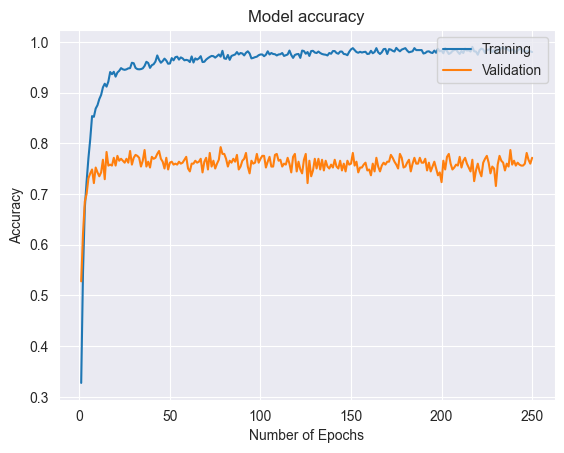

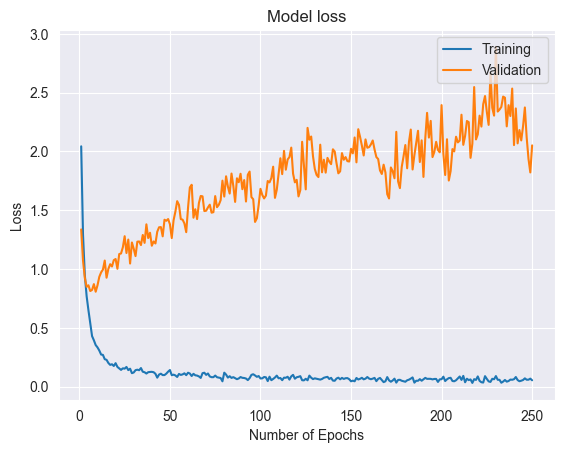

In [31]:
def plot_learningCurve(history, epochs):
  # Plotting the accuracy graph of training & validation
  epoch_range = range(1, epochs+1)
  plt.plot(epoch_range, history.history['accuracy'])
  plt.plot(epoch_range, history.history['val_accuracy'])
  plt.title('Model accuracy')
  plt.ylabel('Accuracy')
  plt.xlabel('Number of Epochs')
  plt.legend(['Training', 'Validation'], loc='upper right')
  plt.show()

  # Plotting the loss graph of training & validation
  plt.plot(epoch_range, history.history['loss'])
  plt.plot(epoch_range, history.history['val_loss'])
  plt.title('Model loss')
  plt.ylabel('Loss')
  plt.xlabel('Number of Epochs')
  plt.legend(['Training', 'Validation'], loc='upper right')
  plt.show()

plot_learningCurve(history, 250)

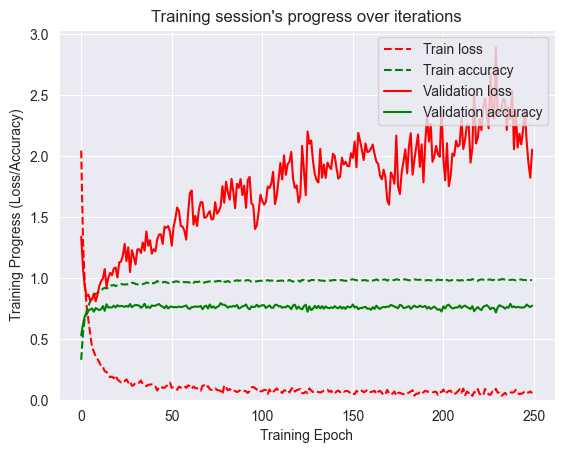

In [32]:
plt.plot(np.array(history.history['loss']), "r--", label = "Train loss")
plt.plot(np.array(history.history['accuracy']), "g--", label = "Train accuracy")
plt.plot(np.array(history.history['val_loss']), "r-", label = "Validation loss")
plt.plot(np.array(history.history['val_accuracy']), "g-", label = "Validation accuracy")
plt.title("Training session's progress over iterations")
plt.legend(loc='upper right')
plt.ylabel('Training Progress (Loss/Accuracy)')
plt.xlabel('Training Epoch')
plt.ylim(0) 
plt.show()

In [33]:
def print_confusion_matrix(confusion_matrix, class_names, figsize = (10,7), fontsize=14):
    df_cm = pd.DataFrame(confusion_matrix, index=class_names, columns=class_names)
    fig = plt.figure(figsize=figsize)
    try:
        heatmap = sns.heatmap(df_cm, annot=True, fmt="d")
    except ValueError:
        raise ValueError("Confusion matrix values must not be integers.")
    heatmap.yaxis.set_ticklabels(heatmap.yaxis.get_ticklabels(), rotation=0, ha='right', fontsize=fontsize)
    heatmap.xaxis.set_ticklabels(heatmap.xaxis.get_ticklabels(), rotation=45, ha='right', fontsize=fontsize)
    plt.ylabel('Truth')
    plt.xlabel('Prediction')
    
truth      = label.classes_.tolist()
prediction = label.classes_.tolist()

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


(<Figure size 500x500 with 1 Axes>,
 <Axes: xlabel='predicted label', ylabel='true label'>)

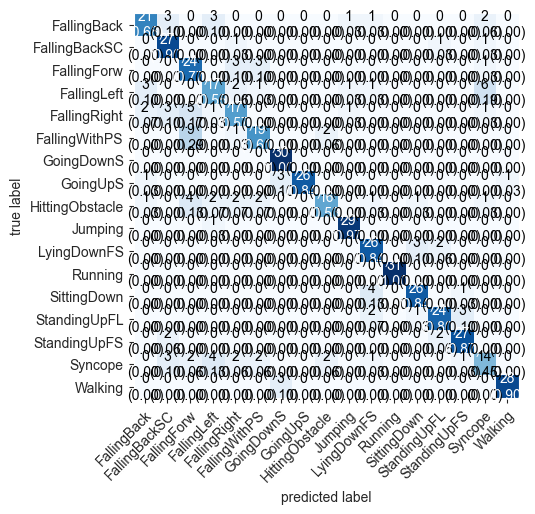

In [36]:
y_pred = np.argmax(model.predict(X_test), axis=-1)
mat = confusion_matrix(y_test, y_pred)
plot_confusion_matrix(conf_mat=mat, class_names=label.classes_, show_normed=True, figsize=(5,5))

In [35]:
print("Precision Score : ", precision_score(y_test, y_pred, average=None))
print("Recall Score : ",    recall_score(y_test,    y_pred, average=None))
print("Accuracy Score :",   accuracy_score(y_test,  y_pred, normalize=True))
print("Loss Score :",       hamming_loss(y_test,    y_pred))

Precision Score :  [0.75       0.71052632 0.54545455 0.60714286 0.60714286 0.7037037
 0.83333333 1.         0.8        0.90625    0.72222222 1.
 0.83870968 0.82758621 0.84375    0.53846154 0.96551724]
Recall Score :  [0.67741935 0.9        0.77419355 0.5483871  0.56666667 0.61290323
 1.         0.83870968 0.53333333 0.96666667 0.83870968 1.
 0.83870968 0.8        0.87096774 0.4516129  0.90322581]
Accuracy Score : 0.7715930902111324
Loss Score : 0.22840690978886757
